#### Machine Learning in Biology - Project's Code
##### Guilherme Henriques & Guilherme Cardoso

In [9]:
# Imports
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from scipy.stats import kruskal
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from scipy.spatial.distance import mahalanobis
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from collections import defaultdict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.pipeline import Pipeline


# Ensure reproductibility of results
np.random.seed(40)
random.seed(40)

<h3 style="color: dodgerblue;">Load dataset and check the data</h3>

In [10]:
# Load dataset
df = pd.read_csv("Phishing.csv")

# Dataset information
print("Dataset shape\n", df.shape)
print("\nDataset head\n", df.head())

# Drop categorical columns
df = df.select_dtypes(exclude=['object', 'category'])
print("\nDataset shape (only numerical features):", df.shape)

Dataset shape
 (235795, 56)

Dataset head
      FILENAME                                 URL  URLLength  \
0  521848.txt    https://www.southbankmosaics.com         31   
1   31372.txt            https://www.uni-mainz.de         23   
2  597387.txt      https://www.voicefmradio.co.uk         29   
3  554095.txt         https://www.sfnmjournal.com         26   
4  151578.txt  https://www.rewildingargentina.org         33   

                       Domain  DomainLength  IsDomainIP  TLD  \
0    www.southbankmosaics.com            24           0  com   
1            www.uni-mainz.de            16           0   de   
2      www.voicefmradio.co.uk            22           0   uk   
3         www.sfnmjournal.com            19           0  com   
4  www.rewildingargentina.org            26           0  org   

   URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  Pay  \
0               100.0              1.000000           0.522907  ...    0   
1               100.0              

<h3 style="color: dodgerblue;">Data preprocessing</h3>

In [11]:
# Check for missing (null) values
print("\nMissing values per column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal missing values in dataset:", df.isnull().sum().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates(ignore_index = True)
print("Duplicate rows removed. New dataset shape:", df.shape)




Missing values per column:
URLLength                     0
DomainLength                  0
IsDomainIP                    0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavicon                    0
Robots                        0
IsResponsive                  0
NoOfURLRedir

<h3 style="color: dodgerblue;">Split features and label</h3>

In [12]:
# Splitting features and target variable
X = df.drop(columns=["label"])  # Drop target variable
y = df["label"]  # Target variable

<h3 style="color: dodgerblue;">Feature Distribution</h3>

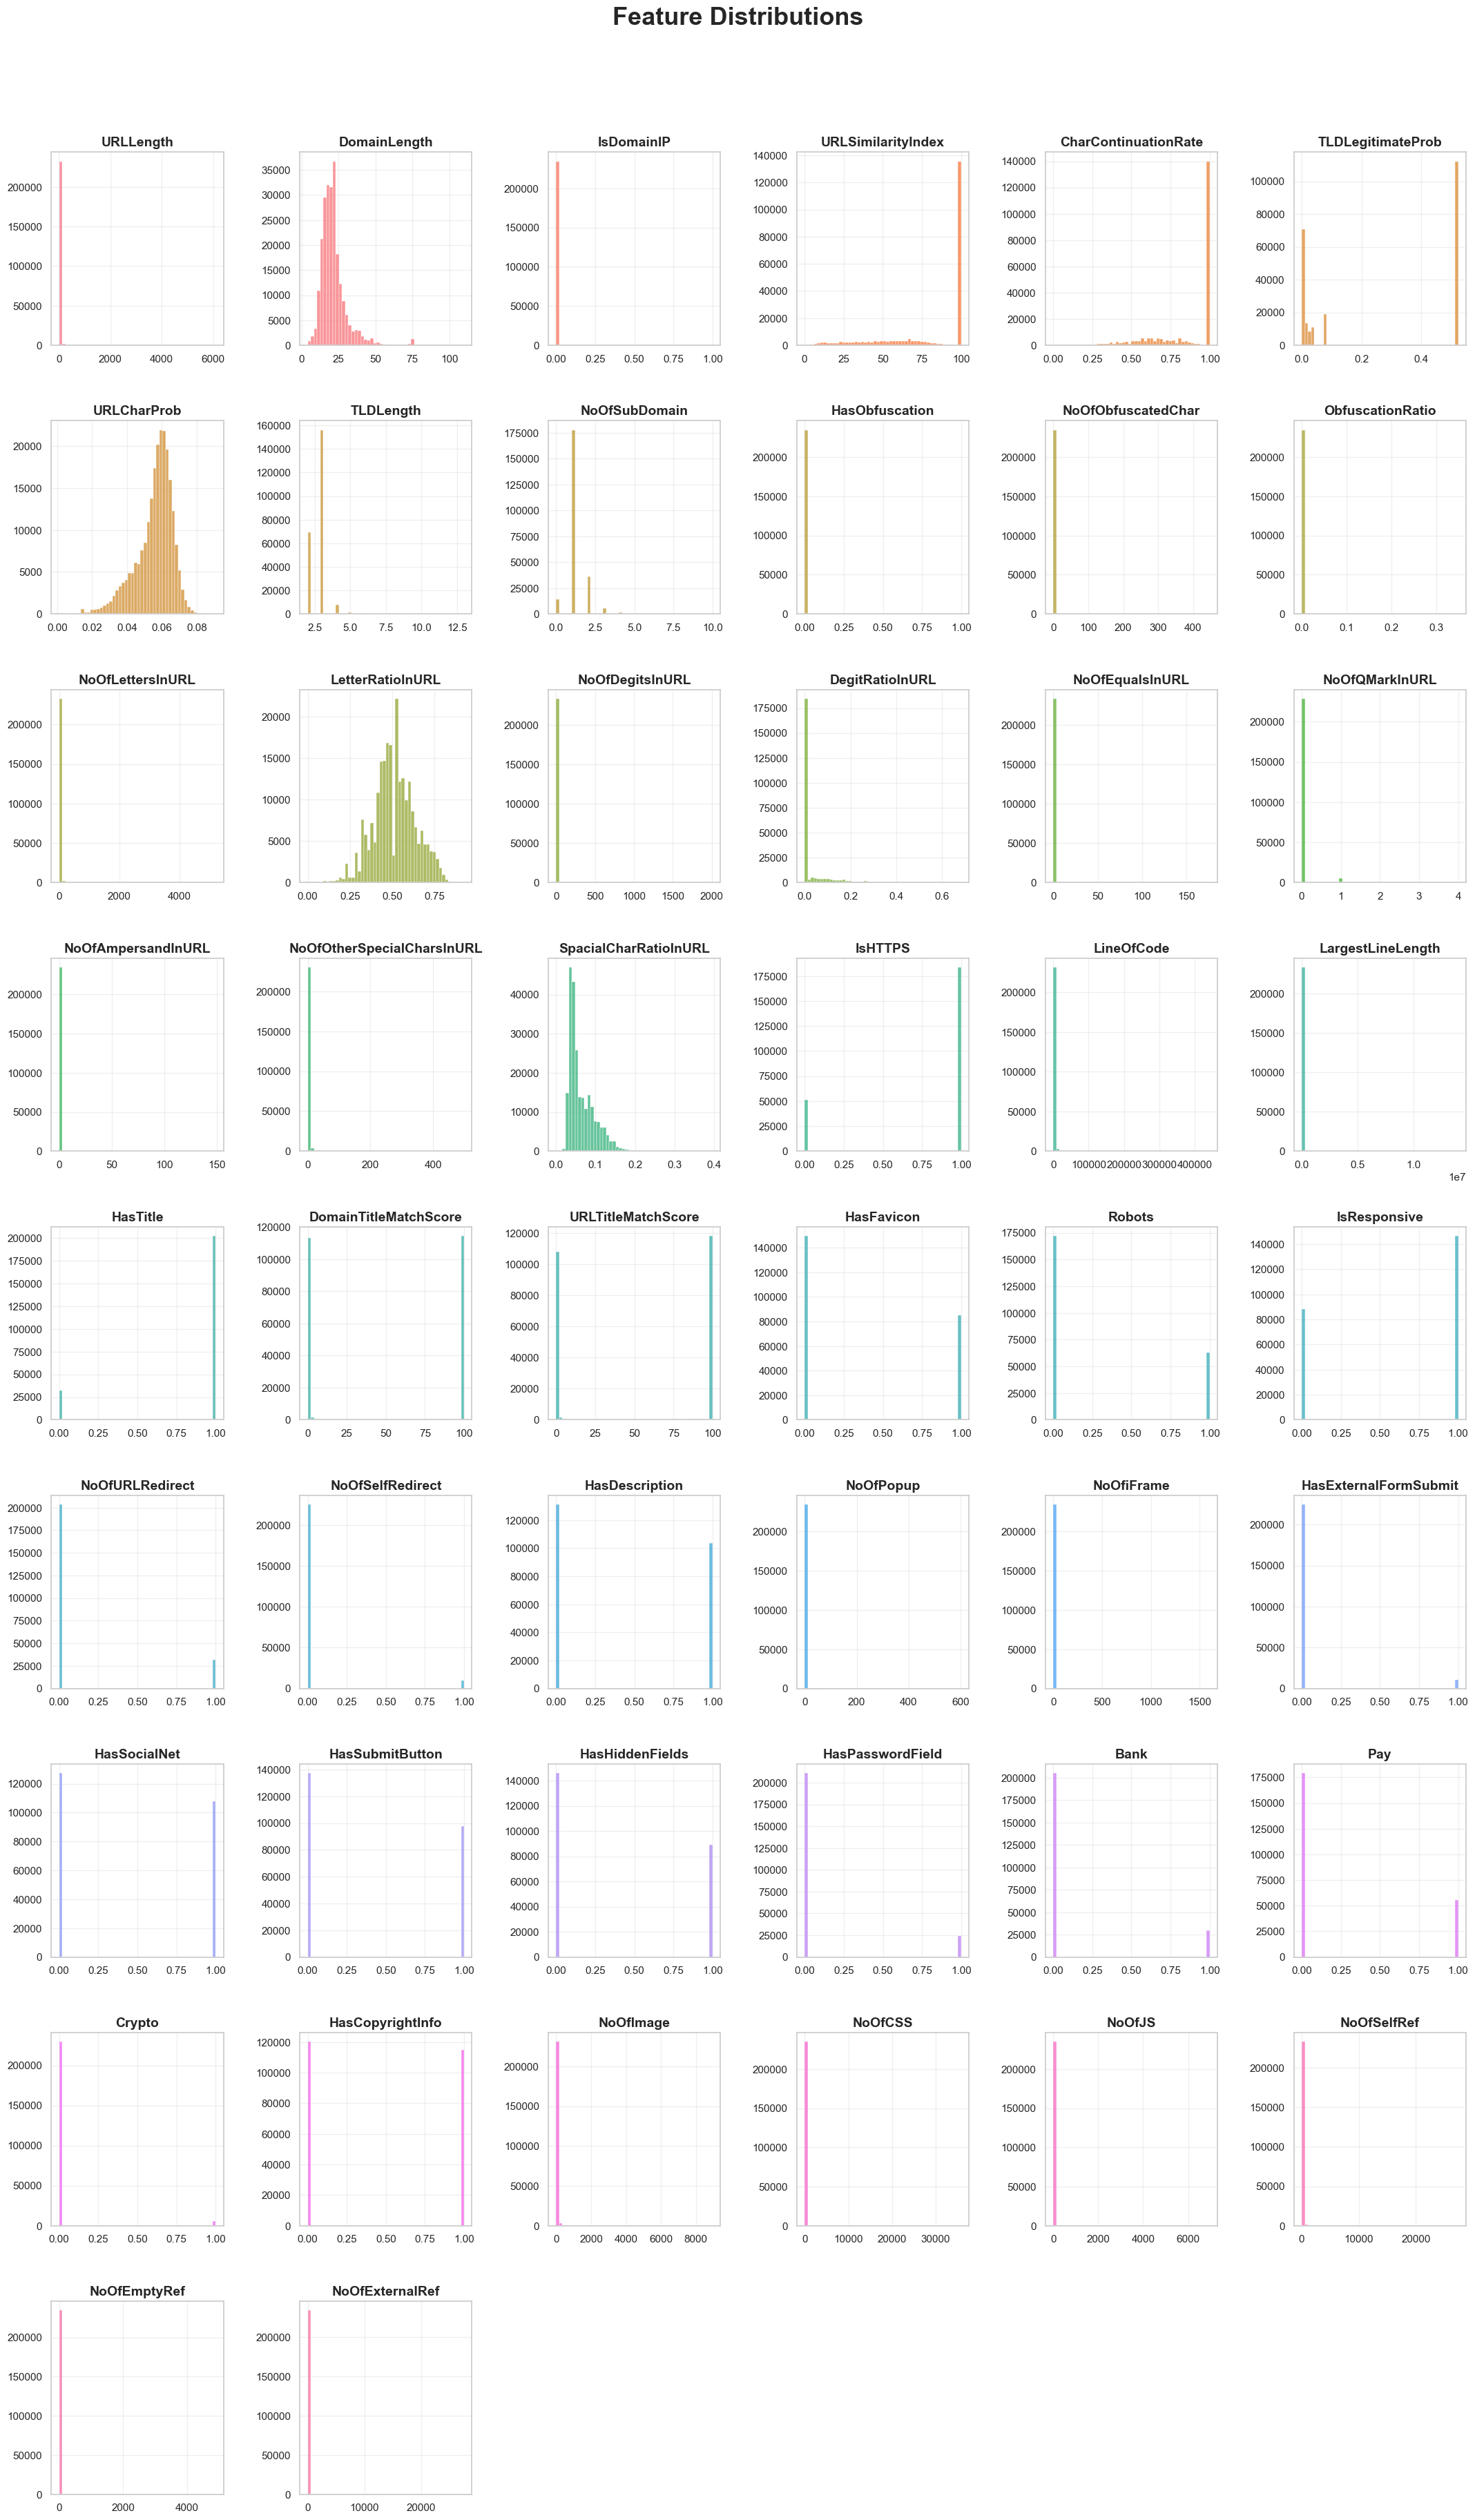

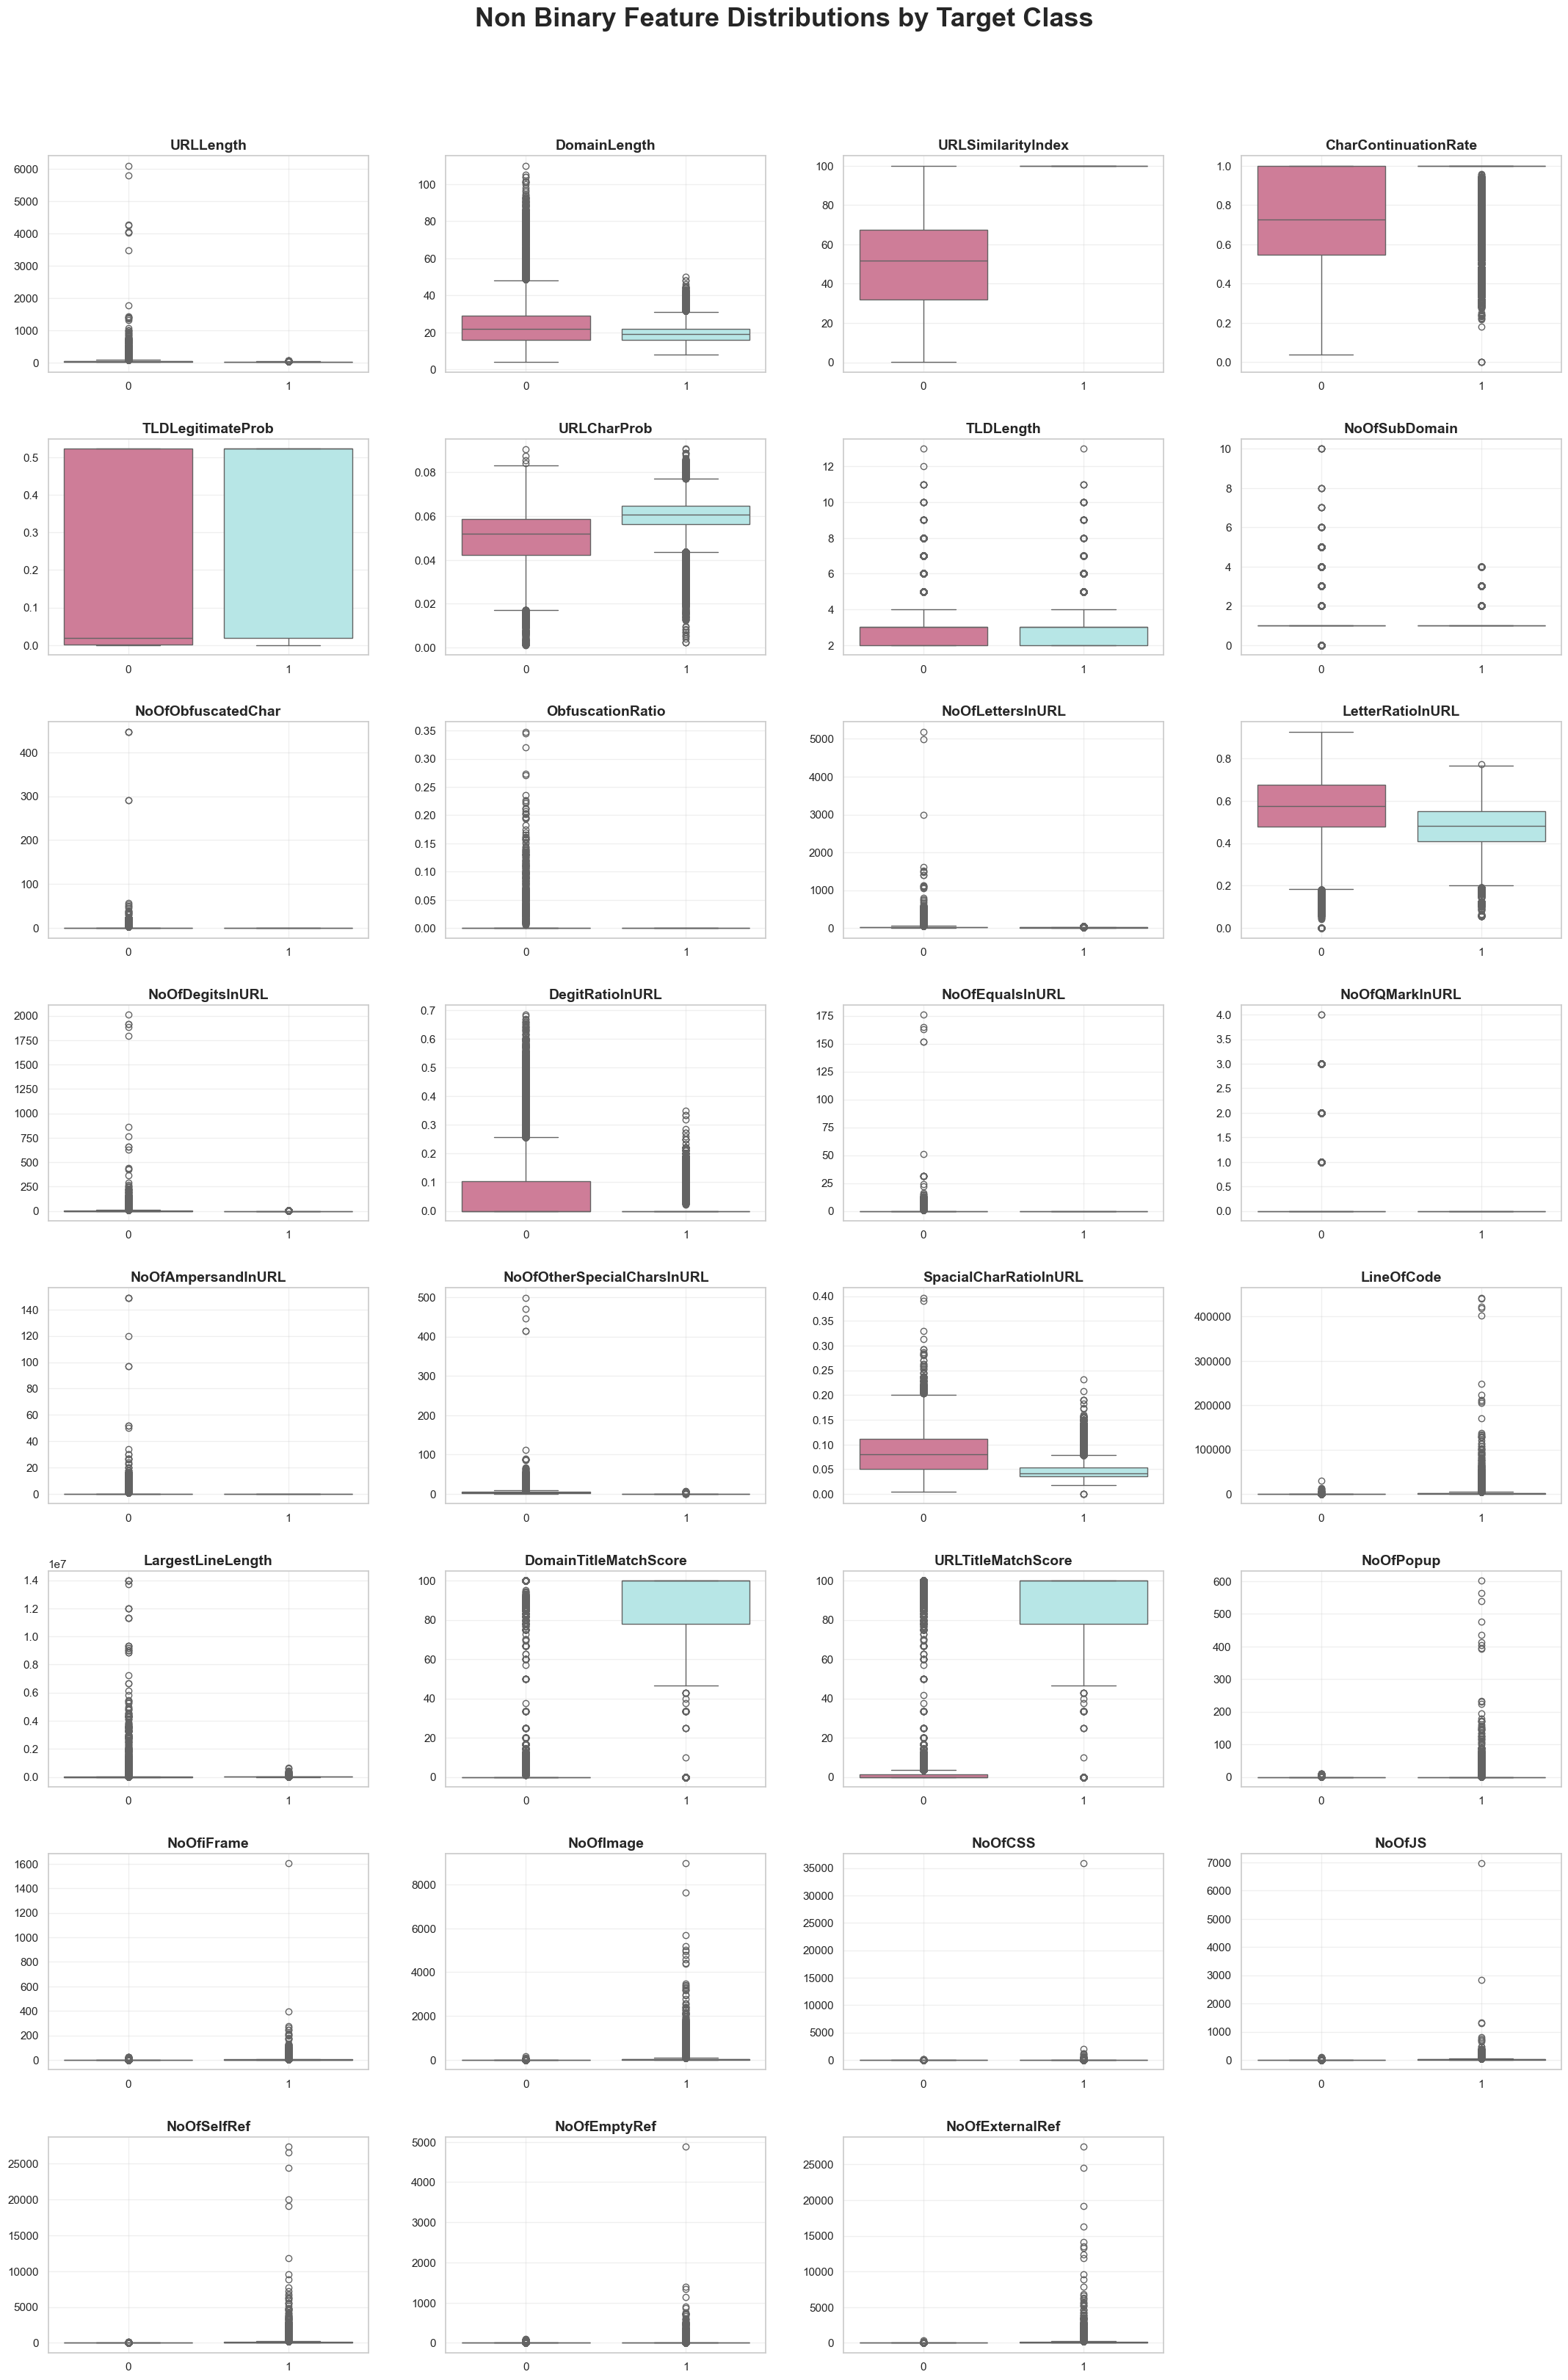

In [13]:
###### HISTOGRAMS ######
sns.set_theme(style="whitegrid")

n_cols = 6  # Number of plots per row
n_features = len(X.columns)
n_rows = int(np.ceil(n_features / n_cols))  # Calculate how many rows needed for the whole plot

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize = (22, n_rows * 4))
axes = axes.flatten()

# Color palette
colors = sns.color_palette("husl", n_features)

# Loop through features and plot each one
for idx, col in enumerate(X.columns):
    sns.histplot(data = X, x = col, bins = 50, color = colors[idx], ax = axes[idx])
    axes[idx].set_title(col, fontsize = 14, weight = 'bold')
    axes[idx].grid(alpha = 0.3)
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")
    axes[idx].tick_params(axis = 'both', labelsize = 11)

# Remove extra empty plots
for ax in axes[n_features:]:
    ax.remove()

# Adjust layout
fig.suptitle("Feature Distributions", fontsize = 26, weight = 'bold', y = 1.02)
plt.tight_layout(pad = 2.5)
plt.show()


###### BOXPLOTS ######

sns.set_theme(style="whitegrid")

# Find non-binary features
non_binary_features = [col for col in X.columns if X[col].nunique() > 2]

# Combine features and target for plot
df_plot = X[non_binary_features].copy()
df_plot['label'] = y

# Color palette
custom_palette = {0: "palevioletred", 1: "paleturquoise"}

n_cols = 4
features = df_plot.drop(columns='label').columns
n_features = len(features)
n_rows = int(np.ceil(n_features / n_cols))

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

# Loop through features and plot each one
for idx, col in enumerate(features):
    sns.boxplot(data = df_plot, x = 'label', y = col, hue = 'label', palette = custom_palette, ax = axes[idx], legend = False)
    axes[idx].set_title(col, fontsize = 14, weight = 'bold')
    axes[idx].grid(alpha = 0.3)
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")
    axes[idx].tick_params(axis = 'both', labelsize = 11)

# Remove extra empty plots
for ax in axes[n_features:]:
    ax.remove()

# Adjust layout
fig.suptitle("Non Binary Feature Distributions by Target Class", fontsize = 26, weight = 'bold', y = 1.02)
plt.tight_layout(pad = 2.5)
plt.show()

<h3 style="color: dodgerblue;">Handle outliers</h3>

In [14]:
# Copy the dataframe to not modify the original
df_wo_outliers = X.copy()

# For each non-binary feature, calculate Q1, Q3, and IQR
for feature in non_binary_features:

    Q1 = df_wo_outliers[feature].quantile(0.25)
    Q3 = df_wo_outliers[feature].quantile(0.75)
    IQR = Q3 - Q1 

    # Identify outliers
    outliers = (df_wo_outliers[feature] < Q1 - 1.5 * IQR) | (df_wo_outliers[feature] > Q3 + 1.5 * IQR)

    # Identify non-outliers
    not_outliers = ~outliers
    
    if np.sum(outliers) != 0:
        # Check if there are any non-outliers before calculating the mean
        if np.sum(not_outliers) > 0:
            mean_non_outliers = df_wo_outliers.loc[not_outliers, feature].mean()  # Calculate mean

            # Ensure the column dtype is float before replacing values
            df_wo_outliers[feature] = df_wo_outliers[feature].astype(float)
            df_wo_outliers.loc[outliers, feature] = mean_non_outliers  # Replace outliers with the mean of non-outliers

# Check shape (should be the same)
print(df_wo_outliers.shape)


(234987, 50)


<h3 style="color: dodgerblue;">Correlation Matrix</h3>

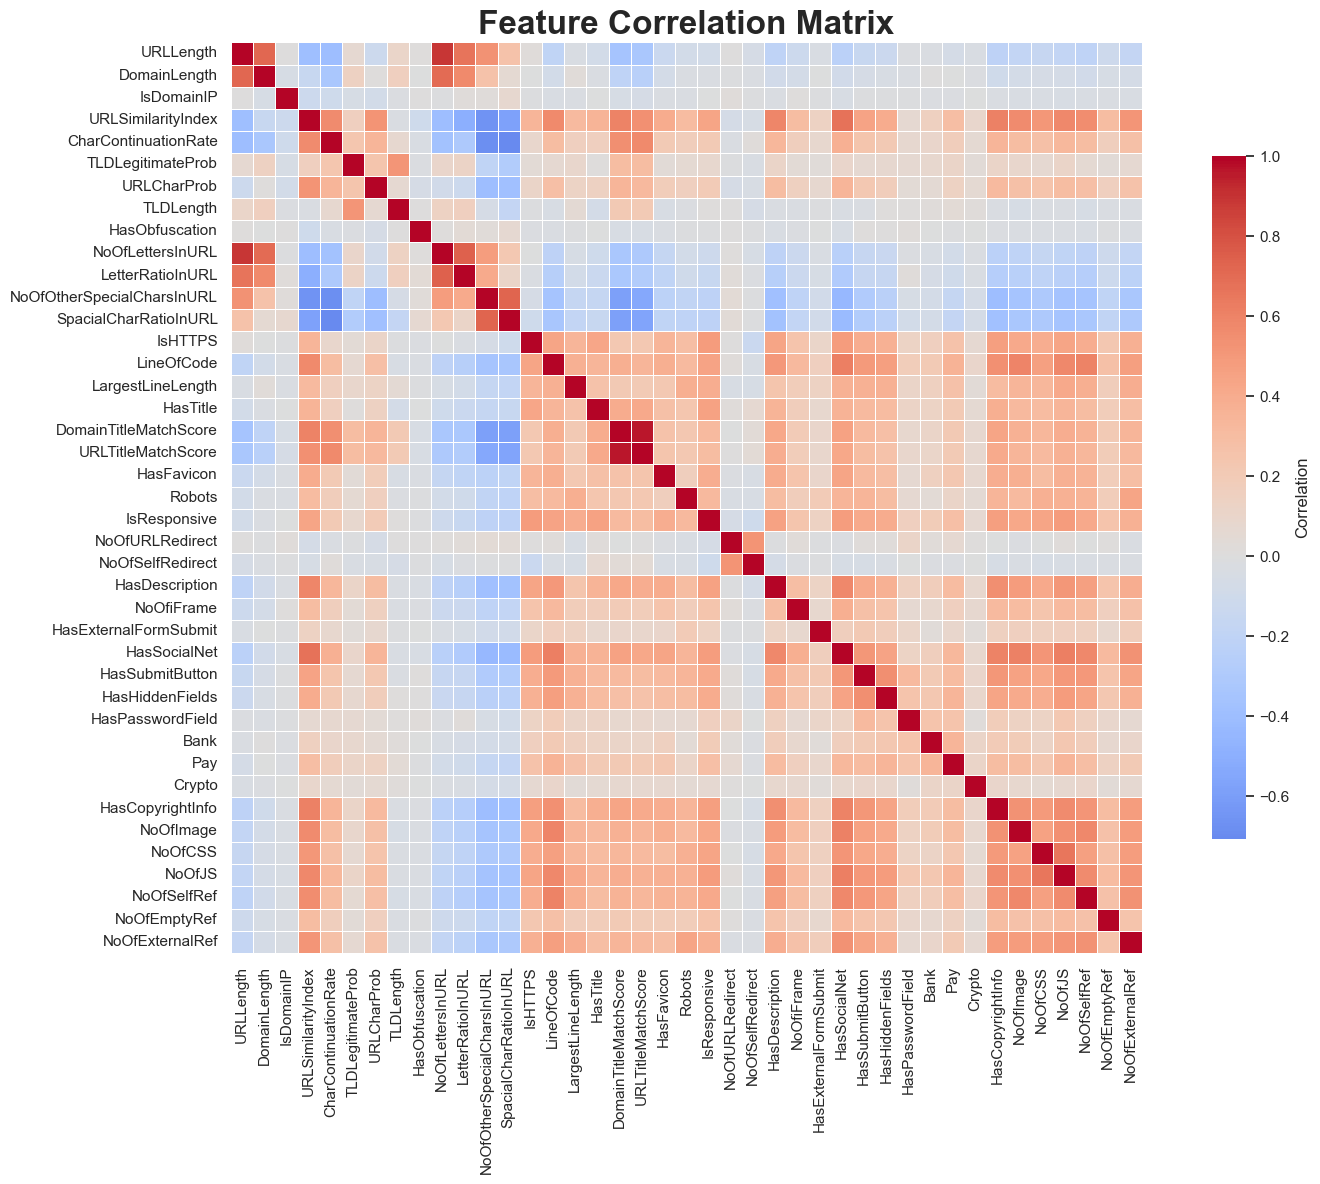

In [15]:
# Drop columns with zero variance (constant columns)
df_wo_outliers_non_constant = df_wo_outliers.loc[:, df_wo_outliers.var() != 0]

# Plot Feature Correlation Matrix
plt.figure(figsize = (16, 12))
sns.heatmap(df_wo_outliers_non_constant.corr(), cmap = "coolwarm", center = 0, square = True, linewidths = 0.5, cbar_kws = {"shrink": 0.75, "label": "Correlation"}, annot = False)
plt.title("Feature Correlation Matrix", fontsize=24, weight='bold')
plt.xticks(rotation = 90)
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()


<h3 style="color: dodgerblue;">Remove highly correlated features and data scaling</h3>

In [16]:
# Remove highly correlated features (> 9.0 or < -0.9)
threshold = 0.9
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation higher than threshold
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Drop those features
X_reduced = df_wo_outliers_non_constant.drop(columns=to_drop)

# Show the removed highly correlated features and check data shape
print(f"Removed {len(to_drop)} features: {to_drop}")
print("\nDataset shape after cleaning:", X_reduced.shape)

# Data scaling with MinMax method
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_reduced)

Removed 2 features: ['NoOfLettersInURL', 'URLTitleMatchScore']

Dataset shape after cleaning: (234987, 39)


<h3 style="color: dodgerblue;">Feature Reduction - PCA</h3>

[0.3423859  0.07435555 0.05502813 0.04656562 0.04472828 0.03510312
 0.03349538 0.03081498 0.03075195 0.02650242 0.02617593 0.02396417
 0.02358906 0.02021899 0.01703986 0.01635432 0.01612961 0.01408517
 0.01292122 0.01159035 0.011017   0.00920641 0.00880676 0.0084308
 0.00733411 0.00689315 0.00634206 0.00561502 0.00538969 0.00520617
 0.00474935 0.00450416 0.00425557 0.00396092 0.00215261 0.00185573
 0.00140392 0.00060389 0.00047269]


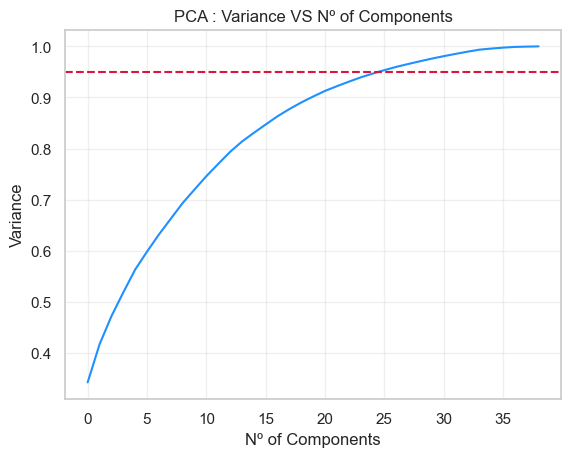

In [17]:
# Create PCA
pca = PCA()
pca.fit(X_scaled)
print(pca.explained_variance_ratio_)

# Plot component x variance
plt.plot(np.cumsum(pca.explained_variance_ratio_), color = "dodgerblue")
plt.xlabel("Nº of Components")
plt.ylabel("Variance")
plt.title("PCA : Variance VS Nº of Components")
plt.grid(alpha = 0.3)

# Line in 0.95% of variance
plt.axhline(y = 0.95, linestyle = "--", color = "crimson")

plt.show()

<h3 style="color: dodgerblue;">Chose the number of components that explain 0.95 of the variance</h3>

In [18]:
# Select nº of components that explain 0.95% of the variance
variance = 0
ncomp = 0

for var in pca.explained_variance_ratio_:
    variance += var
    ncomp += 1 
    if variance >= 0.95:
        break

print(ncomp)

pca = PCA(n_components = ncomp)
X_pca = pca.fit_transform(X_scaled)  # Store selected features

26


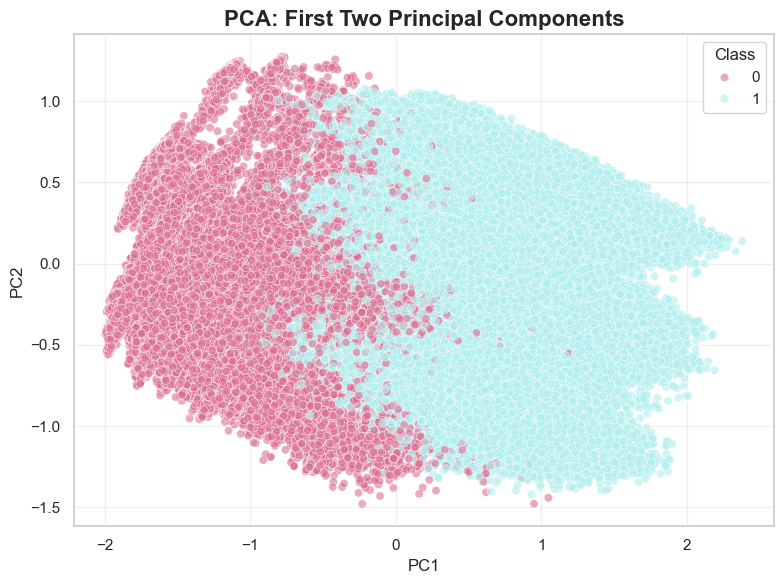

In [19]:
# PCA plot (first two components)
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Label': y
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x = 'PC1', y = 'PC2', hue = 'Label', palette = ["palevioletred", "paleturquoise"], alpha = 0.6)

plt.title('PCA: First Two Principal Components', fontsize = 16, weight = 'bold')
plt.xlabel('PC1', fontsize = 12)
plt.ylabel('PC2', fontsize = 12)
plt.legend(title = 'Class')
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

<h3 style="color: dodgerblue;">Feature Reduction - LDA</h3>

In [20]:
# Create LDA
lda = LDA(n_components = None)
X_lda = lda.fit_transform(X_scaled, y) # Store LDA fitted data

(234987, 1)


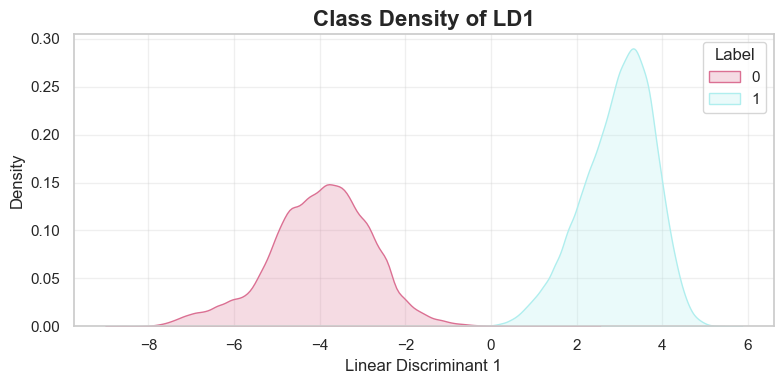

In [ ]:
# Check shape of LDA data (should have 1 column)
print(X_lda.shape)

lda_df = pd.DataFrame({'LD1': X_lda[:, 0], 'Label': y})

# Plot LD1 density plot
plt.figure(figsize = (8, 4))
sns.kdeplot(data = lda_df, x = 'LD1', hue = 'Label', fill = True, palette = ["palevioletred", "paleturquoise"])
plt.title('Class Density of LD1', fontsize = 16, weight = 'bold')
plt.xlabel('Linear Discriminant 1', fontsize = 12)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

<h3 style="color: dodgerblue;">Feature Selection - Kruskal-Wallis</h3>

In [21]:
# Convert scaled features in dataframe
X_scaled_df = pd.DataFrame(X_scaled, columns = X_reduced.columns)

# Find the p-value for each feature
labels = np.unique(y)
p_vals = []
for col in X_scaled_df.columns:
    groups = [X_scaled_df[col][y == label] for label in labels]
    p = kruskal(*groups).pvalue
    p_vals.append(p)

# Create dataframe with p-values
results_df = pd.DataFrame({'feature': X_scaled_df.columns, 'p_value': p_vals}).sort_values(by = 'p_value')

# Show p-values (rounded to 5 decimal places)
print("\n--- Features p-values ---")
for _, row in results_df.iterrows():
    print(f"{row['feature']}: {row['p_value']:.5f}")

# Select features with p-values < 0.05 (threshold level)
selected_features = results_df[results_df['p_value'] < 0.05]['feature']
print(f"\nNumber of selected features: {len(selected_features)}")

# Store the selected features
X_selected = X_scaled_df[selected_features]



--- Features p-values ---
URLLength: 0.00000
DomainLength: 0.00000
URLSimilarityIndex: 0.00000
CharContinuationRate: 0.00000
URLCharProb: 0.00000
TLDLegitimateProb: 0.00000
NoOfOtherSpecialCharsInURL: 0.00000
LetterRatioInURL: 0.00000
LargestLineLength: 0.00000
LineOfCode: 0.00000
SpacialCharRatioInURL: 0.00000
IsHTTPS: 0.00000
HasTitle: 0.00000
Robots: 0.00000
HasFavicon: 0.00000
DomainTitleMatchScore: 0.00000
HasPasswordField: 0.00000
Bank: 0.00000
HasSubmitButton: 0.00000
IsResponsive: 0.00000
NoOfiFrame: 0.00000
HasDescription: 0.00000
HasSocialNet: 0.00000
HasExternalFormSubmit: 0.00000
Pay: 0.00000
Crypto: 0.00000
HasHiddenFields: 0.00000
NoOfSelfRef: 0.00000
NoOfJS: 0.00000
NoOfCSS: 0.00000
NoOfImage: 0.00000
HasCopyrightInfo: 0.00000
NoOfExternalRef: 0.00000
NoOfEmptyRef: 0.00000
NoOfSelfRedirect: 0.00000
IsDomainIP: 0.00000
HasObfuscation: 0.00000
NoOfURLRedirect: 0.00000
TLDLength: 0.00000

Number of selected features: 39


<h3 style="color: dodgerblue;">Evaluation metrics and cross-validation functions</h3>

In [ ]:
# Evaluation metrics function
def evaluate(y_true, y_pred):
    """
    Parameters:
    - y_true: True binary labels (0 or 1).
    - y_pred: Predicted binary labels (0 or 1).

    Returned metric scores:
    - acc: Accuracy
    - f1: F1 score (harmonic mean of precision and recall)
    - sensitivity: True Positive Rate
    - specificity: True Negative Rate
    """
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average = "binary")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    return acc, f1, sensitivity, specificity

# Stratified K-Fold Cross-validation for classifiers function
def cross_validate_classifier(X, y, classifier_func, folds = 5):
    """
    Parameters:
    - X: Feature matrix
    - y: True labels of the samples
    - classifier_func: A function of a classifier that return the predictions
    - folds: Number of splits (folds) for cross-validation.

    Returns:
    - metrics: dictionary containing the average evaluation metrics and the standard deviations.
    """
    skf = StratifiedKFold(n_splits = folds, shuffle = True, random_state = 40)
    results = defaultdict(list)
    
    # Store the true and predicted labels across all folds for the final confusion matrix
    all_y_true = []
    all_y_pred = []

    # Perform cross-validation
    for train_idx, test_idx in skf.split(X, y):
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        # Get the model's predictions
        y_pred = classifier_func(X_train, y_train, X_test)
        
        # Evaluate and store the metrics
        acc, f1, sens, spec = evaluate(y_test, y_pred)
        results["accuracy"].append(acc)
        results["f1"].append(f1)
        results["sensitivity"].append(sens)
        results["specificity"].append(spec)
        
        # Append true and predicted values for the final confusion matrix
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    # Calculate the average metrics with their standard deviations
    metrics = {metric: (round(float(np.mean(vals)), 4), round(float(np.std(vals)), 4)) for metric, vals in results.items()}
    print(metrics)
    
    # Calculate the overall confusion matrix after cross-validation
    cm = confusion_matrix(all_y_true, all_y_pred)
    print(f"\nOverall Confusion Matrix:\n{cm}")
    
    # Return the metrics
    return metrics


<h3 style="color: dodgerblue;">Classifiers (MDC - euclidean distance ; MDC - malanobis distance; Fisher-LDA ; GNB ; KNN ; SVM)</h3>

In [ ]:
# Minimum Distance Classifiers
# Compute centroids and covariance matrices
def compute_class_stats(X, y):

    classes = np.unique(y)
    centroids = {}
    cov_matrices = {}
    for cls in classes:
        X_cls = X[y == cls]
        centroids[cls] = np.mean(X_cls, axis = 0)
        cov_matrices[cls] = np.cov(X_cls, rowvar = False)

    return centroids, cov_matrices

# Euclidean distance classifier
def euclidean_classifier(X_train, y_train, X_test):

    centroids, _ = compute_class_stats(X_train, y_train)
    preds = []
    for x in X_test:
        distances = {cls: np.linalg.norm(x - centroid) for cls, centroid in centroids.items()}
        preds.append(min(distances, key = distances.get))

    return np.array(preds)

# Mahalanobis distance classifier
def mahalanobis_classifier(X_train, y_train, X_test):

    centroids, cov_matrices = compute_class_stats(X_train, y_train)
    preds = []
    pooled_cov = np.atleast_2d(np.cov(X_train, rowvar = False))
    inv_cov = np.linalg.pinv(pooled_cov)
    for x in X_test:
        distances = {cls: mahalanobis(x, centroid, inv_cov) for cls, centroid in centroids.items()}
        preds.append(min(distances, key = distances.get))

    return np.array(preds)

# Fisher-LDA
def fisher_lda_model(X_train, y_train, X_test):

    lda = LDA()
    lda.fit(X_train, y_train)

    return lda.predict(X_test)

# KNN
def knn_model(X_train, y_train, X_test):

    knn = KNeighborsClassifier(n_neighbors = 3)
    knn.fit(X_train, y_train)

    return knn.predict(X_test)

# Gaussian Naive Bayes
def gnb_model(X_train, y_train, X_test):

    gnb = GaussianNB()
    gnb.fit(X_train, y_train)

    return gnb.predict(X_test)

# SVM
def svm_model(X_train, y_train, X_test):

    svm = SVC(kernel = 'rbf')
    svm.fit(X_train, y_train)
    
    return svm.predict(X_test)


<h3 style="color: dodgerblue;">Classifiers results with all features</h3>

In [ ]:
# Print the averaged metrics and their standard deviations for each classifier

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_scaled, y, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_scaled, y, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_scaled, y, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_scaled, y, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_scaled, y, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_scaled, y, svm_model)

Euclidean Classifier:
{'accuracy': (0.976, 0.0007), 'f1': (0.9789, 0.0006), 'sensitivity': (0.9709, 0.0011), 'specificity': (0.9829, 0.0014)}

Overall Confusion Matrix:
[[ 98421   1716]
 [  3922 130928]]

Mahalanobis Classifier:
{'accuracy': (0.9993, 0.0001), 'f1': (0.9994, 0.0001), 'sensitivity': (1.0, 0.0), 'specificity': (0.9983, 0.0003)}

Overall Confusion Matrix:
[[ 99971    166]
 [     0 134850]]

Fisher-LDA:
{'accuracy': (0.9992, 0.0001), 'f1': (0.9993, 0.0001), 'sensitivity': (1.0, 0.0), 'specificity': (0.9982, 0.0003)}

Overall Confusion Matrix:
[[ 99957    180]
 [     0 134850]]

KNN:
{'accuracy': (0.9975, 0.0004), 'f1': (0.9978, 0.0003), 'sensitivity': (0.9986, 0.0003), 'specificity': (0.996, 0.0007)}

Overall Confusion Matrix:
[[ 99740    397]
 [   193 134657]]

Gaussian Naive Bayes:
{'accuracy': (0.9997, 0.0001), 'f1': (0.9997, 0.0), 'sensitivity': (0.9995, 0.0001), 'specificity': (0.9998, 0.0001)}

Overall Confusion Matrix:
[[100119     18]
 [    64 134786]]

SVM:
{'accur

<h3 style="color: dodgerblue;">Classifiers results with PCA features</h3>

In [ ]:
# Print the averaged metrics and their standard deviations for each classifier

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_pca, y, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_pca, y, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_pca, y, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_pca, y, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_pca, y, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_pca, y, svm_model)

Euclidean Classifier:
{'accuracy': (0.9759, 0.0007), 'f1': (0.9788, 0.0006), 'sensitivity': (0.9708, 0.0011), 'specificity': (0.9827, 0.0014)}

Overall Confusion Matrix:
[[ 98406   1731]
 [  3941 130909]]

Mahalanobis Classifier:
{'accuracy': (0.9989, 0.0002), 'f1': (0.999, 0.0002), 'sensitivity': (0.9994, 0.0001), 'specificity': (0.9981, 0.0005)}

Overall Confusion Matrix:
[[ 99942    195]
 [    75 134775]]

Fisher-LDA:
{'accuracy': (0.9988, 0.0002), 'f1': (0.999, 0.0002), 'sensitivity': (0.9995, 0.0001), 'specificity': (0.9979, 0.0004)}

Overall Confusion Matrix:
[[ 99923    214]
 [    61 134789]]

KNN:
{'accuracy': (0.9971, 0.0004), 'f1': (0.9975, 0.0003), 'sensitivity': (0.9981, 0.0003), 'specificity': (0.9958, 0.0007)}

Overall Confusion Matrix:
[[ 99715    422]
 [   256 134594]]

Gaussian Naive Bayes:
{'accuracy': (0.9556, 0.0007), 'f1': (0.9622, 0.0006), 'sensitivity': (0.9851, 0.0009), 'specificity': (0.9158, 0.0021)}

Overall Confusion Matrix:
[[ 91707   8430]
 [  2009 132841]

<h3 style="color: dodgerblue;">Classifiers results with LDA features</h3>

In [ ]:
# Print the averaged metrics and their standard deviations for each classifier

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_lda, y, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_lda, y, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_lda, y, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_lda, y, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_lda, y, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_lda, y, svm_model)

Euclidean Classifier:
{'accuracy': (0.9993, 0.0001), 'f1': (0.9994, 0.0001), 'sensitivity': (1.0, 0.0), 'specificity': (0.9984, 0.0003)}

Overall Confusion Matrix:
[[ 99973    164]
 [     0 134850]]

Mahalanobis Classifier:
{'accuracy': (0.9993, 0.0001), 'f1': (0.9994, 0.0001), 'sensitivity': (1.0, 0.0), 'specificity': (0.9984, 0.0003)}

Overall Confusion Matrix:
[[ 99973    164]
 [     0 134850]]

Fisher-LDA:
{'accuracy': (0.9992, 0.0001), 'f1': (0.9993, 0.0001), 'sensitivity': (1.0, 0.0), 'specificity': (0.9982, 0.0003)}

Overall Confusion Matrix:
[[ 99958    179]
 [     0 134850]]

KNN:
{'accuracy': (0.9997, 0.0001), 'f1': (0.9997, 0.0001), 'sensitivity': (0.9998, 0.0001), 'specificity': (0.9994, 0.0002)}

Overall Confusion Matrix:
[[100078     59]
 [    23 134827]]

Gaussian Naive Bayes:
{'accuracy': (0.9997, 0.0001), 'f1': (0.9997, 0.0001), 'sensitivity': (0.9998, 0.0001), 'specificity': (0.9995, 0.0002)}

Overall Confusion Matrix:
[[100085     52]
 [    24 134826]]

SVM:
{'accura

<h3 style="color: dodgerblue;">Handle Class Imbalance</h3>

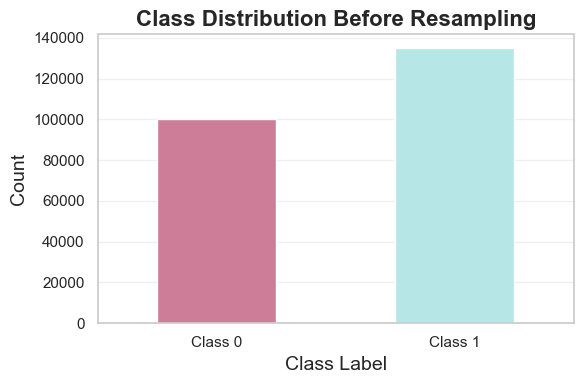

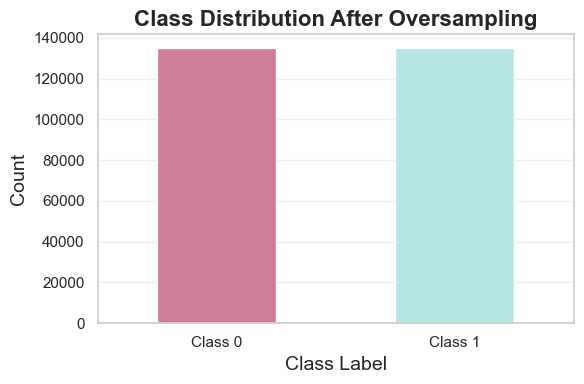

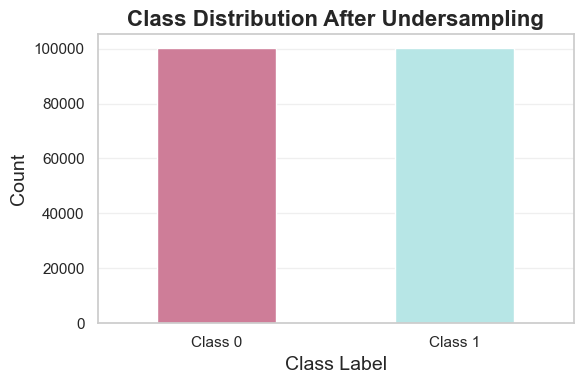

In [ ]:
# Plot class imbalance
sns.set_theme(style="whitegrid")

custom_palette = {np.int64(0): "palevioletred", np.int64(1): "paleturquoise"}
plt.figure(figsize = (6, 4))
sns.countplot(x = y, hue = y, palette = custom_palette, legend = False, width = 0.5)
plt.title("Class Distribution Before Resampling", fontsize = 16, weight = "bold")
plt.xlabel("Class Label", fontsize = 14)
plt.ylabel("Count", fontsize = 14)
plt.xticks(ticks = [0, 1], labels=["Class 0", "Class 1"])
ax = plt.gca()
for gridline in ax.get_ygridlines():
    gridline.set_alpha(0.3)
plt.tight_layout()
plt.show()

# Apply resampling methods
ros = RandomOverSampler(random_state = 40)
rus = RandomUnderSampler(random_state = 40)

# Oversample data
X_oversampled, y_oversampled = ros.fit_resample(X_reduced, y)

# Undersample data
X_undersampled, y_undersampled = rus.fit_resample(X_reduced, y)

# Reset indexs to avoid errors
X_undersampled = X_undersampled.reset_index(drop = True)
y_undersampled = y_undersampled.reset_index(drop = True)

# Scale data
scaler = MinMaxScaler()
X_oversampled_scaled = scaler.fit_transform(X_oversampled)
X_undersampled_scaled = scaler.fit_transform(X_undersampled)

# Plot after oversampling
plt.figure(figsize=(6, 4))
sns.countplot(x=y_oversampled, hue = y_oversampled, palette = custom_palette, legend = False, width = 0.5)
plt.title("Class Distribution After Oversampling", fontsize = 16, weight = 'bold')
plt.xlabel("Class Label", fontsize=14)
plt.ylabel("Count", fontsize = 14)
plt.xticks(ticks = [0, 1], labels = ["Class 0", "Class 1"])
ax = plt.gca()
for gridline in ax.get_ygridlines():
    gridline.set_alpha(0.3)
plt.tight_layout()
plt.show()

# Plot after undersampling
plt.figure(figsize = (6, 4))
sns.countplot(x = y_undersampled, hue = y_undersampled, palette = custom_palette, legend = False, width = 0.5)
plt.title("Class Distribution After Undersampling", fontsize = 16, weight = "bold")
plt.xlabel("Class Label", fontsize = 14)
plt.ylabel("Count", fontsize = 14)
plt.xticks(ticks = [0, 1], labels=["Class 0", "Class 1"])
ax = plt.gca()
for gridline in ax.get_ygridlines():
    gridline.set_alpha(0.3)
plt.tight_layout()
plt.show()



<h3 style="color: dodgerblue;">PCA and LDA on resampled data</h3>

In [21]:
# PCA on resampled data (same number of components)
X_pca_oversampled = pca.transform(X_oversampled_scaled)
X_pca_undersampled = pca.transform(X_undersampled_scaled)

# LDA on resampled data
X_lda_oversampled = lda.transform(X_oversampled_scaled)
X_lda_undersampled = lda.transform(X_undersampled_scaled)

<h3 style="color: dodgerblue;">Classifiers results with all features - with resampled data</h3>

In [ ]:
# Print the averaged metrics and their standard deviations for each classifier

print("----- Results with oversampled data -----\n")

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_oversampled_scaled, y_oversampled, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_oversampled_scaled, y_oversampled, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_oversampled_scaled, y_oversampled, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_oversampled_scaled, y_oversampled, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_oversampled_scaled, y_oversampled, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_oversampled_scaled, y_oversampled, svm_model)


print("\n----- Results with undersampler data -----\n")

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_undersampled_scaled, y_undersampled, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_undersampled_scaled, y_undersampled, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_undersampled_scaled, y_undersampled, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_undersampled_scaled, y_undersampled, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_undersampled_scaled, y_undersampled, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_undersampled_scaled, y_undersampled, svm_model)

----- Results with oversampled data -----

Euclidean Classifier:
{'accuracy': (0.977, 0.0004), 'f1': (0.9768, 0.0004), 'sensitivity': (0.971, 0.001), 'specificity': (0.9829, 0.0006)}

Overall Confusion Matrix:
[[132550   2300]
 [  3914 130936]]

Mahalanobis Classifier:
{'accuracy': (0.9993, 0.0001), 'f1': (0.9993, 0.0001), 'sensitivity': (0.9999, 0.0), 'specificity': (0.9987, 0.0001)}

Overall Confusion Matrix:
[[134669    181]
 [    10 134840]]

Fisher-LDA:
{'accuracy': (0.9993, 0.0001), 'f1': (0.9993, 0.0001), 'sensitivity': (0.9999, 0.0), 'specificity': (0.9987, 0.0001)}

Overall Confusion Matrix:
[[134669    181]
 [    10 134840]]

KNN:
{'accuracy': (0.9976, 0.0001), 'f1': (0.9976, 0.0001), 'sensitivity': (0.9981, 0.0002), 'specificity': (0.997, 0.0003)}

Overall Confusion Matrix:
[[134449    401]
 [   259 134591]]

Gaussian Naive Bayes:
{'accuracy': (0.9997, 0.0001), 'f1': (0.9997, 0.0001), 'sensitivity': (0.9995, 0.0001), 'specificity': (0.9998, 0.0001)}

Overall Confusion Matrix

<h3 style="color: dodgerblue;">Classifiers results with PCA features - with resampled data</h3>

In [ ]:
# Print the averaged metrics and their standard deviations for each classifier

print("----- Results with oversampled data -----\n")

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_pca_oversampled, y_oversampled, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_pca_oversampled, y_oversampled, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_pca_oversampled, y_oversampled, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_pca_oversampled, y_oversampled, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_pca_oversampled, y_oversampled, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_pca_oversampled, y_oversampled, svm_model)


print("\n----- Results with undersampler data -----\n")

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_pca_undersampled, y_undersampled, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_pca_undersampled, y_undersampled, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_pca_undersampled, y_undersampled, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_pca_undersampled, y_undersampled, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_pca_undersampled, y_undersampled, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_pca_undersampled, y_undersampled, svm_model)

----- Results with oversampled data -----

Euclidean Classifier:
{'accuracy': (0.9768, 0.0005), 'f1': (0.9767, 0.0005), 'sensitivity': (0.9708, 0.001), 'specificity': (0.9828, 0.0006)}

Overall Confusion Matrix:
[[132532   2318]
 [  3937 130913]]

Mahalanobis Classifier:
{'accuracy': (0.9985, 0.0001), 'f1': (0.9985, 0.0001), 'sensitivity': (0.9985, 0.0002), 'specificity': (0.9985, 0.0001)}

Overall Confusion Matrix:
[[134646    204]
 [   207 134643]]

Fisher-LDA:
{'accuracy': (0.9985, 0.0001), 'f1': (0.9985, 0.0001), 'sensitivity': (0.9985, 0.0002), 'specificity': (0.9985, 0.0001)}

Overall Confusion Matrix:
[[134646    204]
 [   207 134643]]

KNN:
{'accuracy': (0.9972, 0.0001), 'f1': (0.9972, 0.0001), 'sensitivity': (0.9976, 0.0003), 'specificity': (0.9967, 0.0002)}

Overall Confusion Matrix:
[[134411    439]
 [   320 134530]]

Gaussian Naive Bayes:
{'accuracy': (0.951, 0.0012), 'f1': (0.9525, 0.0011), 'sensitivity': (0.9839, 0.0007), 'specificity': (0.9181, 0.0024)}

Overall Confusio

<h3 style="color: dodgerblue;">Classifiers results with LDA features - with resampled data</h3>

In [ ]:
# Print the averaged metrics and their standard deviations for each classifier

print("----- Results with oversampled data -----\n")

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_lda_oversampled, y_oversampled, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_lda_oversampled, y_oversampled, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_lda_oversampled, y_oversampled, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_lda_oversampled, y_oversampled, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_lda_oversampled, y_oversampled, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_lda_oversampled, y_oversampled, svm_model)


print("\n----- Results with undersampler data -----\n")

print("Euclidean Classifier:")
euclidean_results = cross_validate_classifier(X_lda_undersampled, y_undersampled, euclidean_classifier)

print("\nMahalanobis Classifier:")
mahalanobis_results = cross_validate_classifier(X_lda_undersampled, y_undersampled, mahalanobis_classifier)

print("\nFisher-LDA:")
fisher_lda_results = cross_validate_classifier(X_lda_undersampled, y_undersampled, fisher_lda_model)

print("\nKNN:")
knn_results = cross_validate_classifier(X_lda_undersampled, y_undersampled, knn_model)

print("\nGaussian Naive Bayes:")
gnb_results = cross_validate_classifier(X_lda_undersampled, y_undersampled, gnb_model)

print("\nSVM:")
svm_results = cross_validate_classifier(X_lda_undersampled, y_undersampled, svm_model)

----- Results with oversampled data -----

Euclidean Classifier:
{'accuracy': (0.9991, 0.0001), 'f1': (0.9991, 0.0001), 'sensitivity': (1.0, 0.0), 'specificity': (0.9983, 0.0002)}

Overall Confusion Matrix:
[[134620    230]
 [     0 134850]]

Mahalanobis Classifier:
{'accuracy': (0.9991, 0.0001), 'f1': (0.9991, 0.0001), 'sensitivity': (1.0, 0.0), 'specificity': (0.9983, 0.0002)}

Overall Confusion Matrix:
[[134620    230]
 [     0 134850]]

Fisher-LDA:
{'accuracy': (0.9991, 0.0001), 'f1': (0.9991, 0.0001), 'sensitivity': (1.0, 0.0), 'specificity': (0.9983, 0.0002)}

Overall Confusion Matrix:
[[134620    230]
 [     0 134850]]

KNN:
{'accuracy': (0.9995, 0.0001), 'f1': (0.9995, 0.0001), 'sensitivity': (0.9997, 0.0001), 'specificity': (0.9994, 0.0002)}

Overall Confusion Matrix:
[[134774     76]
 [    46 134804]]

Gaussian Naive Bayes:
{'accuracy': (0.9996, 0.0001), 'f1': (0.9996, 0.0001), 'sensitivity': (0.9997, 0.0001), 'specificity': (0.9995, 0.0001)}

Overall Confusion Matrix:
[[1347

<h3 style="color: dodgerblue;">Hyperparameter tuning for KNN and SVM</h3>

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best KNN Parameters: {'knn__n_neighbors': 3}

KNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30041
           1       1.00      1.00      1.00     40456

    accuracy                           1.00     70497
   macro avg       1.00      1.00      1.00     70497
weighted avg       1.00      1.00      1.00     70497

KNN ROC AUC: 0.9988325962098716

Best KNN Metrics:

{'accuracy': (0.9975, 0.0004), 'f1': (0.9978, 0.0003), 'sensitivity': (0.9986, 0.0003), 'specificity': (0.996, 0.0007)}

Overall Confusion Matrix:
[[ 99740    397]
 [   193 134657]]
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best SVM Parameters: {'svc__C': 10, 'svc__kernel': 'linear'}

SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30041
           1       1.00      1.00      1.00  

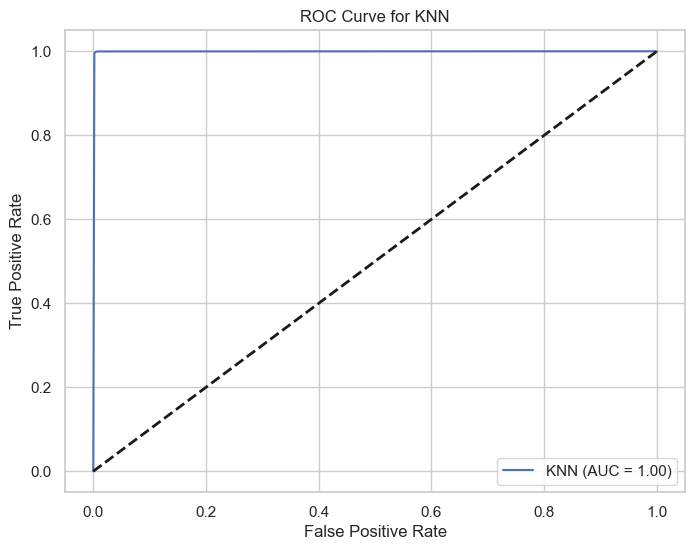

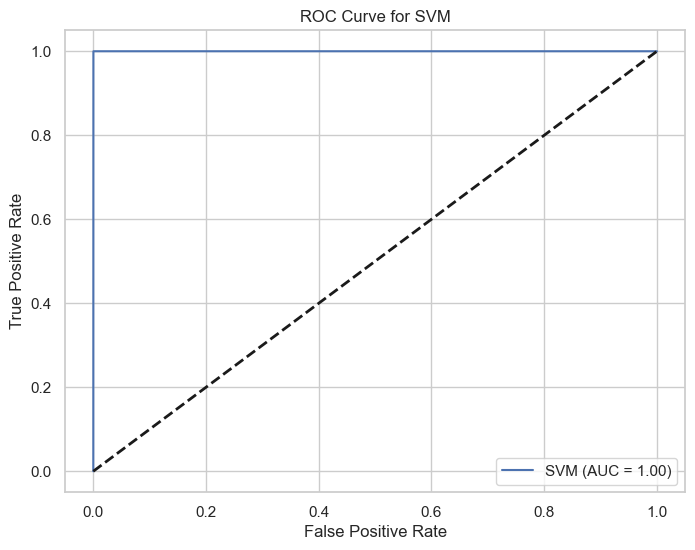

In [ ]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, stratify = y, random_state = 40)

# --------------- KNN Parameter Tuning ---------------
knn_pipeline = Pipeline([("knn", KNeighborsClassifier())])

# Evaluate some odd number of neighbors
knn_params = {"knn__n_neighbors": list(range(3, 20, 2))}

# Grid search to find the best hyperparameter value based on F1 score
knn_grid = GridSearchCV(knn_pipeline, knn_params, cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 40), scoring = "f1", n_jobs = -1, verbose = 1)
knn_grid.fit(X_train, y_train)

# Make predictions with best KNN model
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)
y_proba_knn = best_knn.predict_proba(X_test)[:, 1]

# Print best KNN results
print("Best KNN Parameters:", knn_grid.best_params_)
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("KNN ROC AUC:", roc_auc_score(y_test, y_proba_knn))

# Cross-validation for best KNN for additional metrics
best_nb = knn_grid.best_params_["knn__n_neighbors"]

def best_knn(X_train, y_train, X_test):

    knn = KNeighborsClassifier(n_neighbors = best_nb)
    knn.fit(X_train, y_train)

    return knn.predict(X_test)

# Show the metrics for the best KNN
print("\nBest KNN Metrics:\n")
knn_metrics = cross_validate_classifier(X_scaled, y, best_knn, folds = 5)


# --------------- SVM Parameter Tuning ---------------
svm_pipeline = Pipeline([("svc", SVC(probability = True))])

# Evaluate some values of C and kernel
svm_params = {
    "svc__kernel": ["linear", "rbf"],
    "svc__C": [0.1, 1, 10]
    }

# Grid search to find the best hyperparameter values based on F1 score
svm_grid = GridSearchCV(svm_pipeline, svm_params, cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 40), scoring = "f1", n_jobs = -1, verbose = 1)
svm_grid.fit(X_train, y_train)

# Make predictions with best SVM model
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]

# Print best SVM results
print("\nBest SVM Parameters:", svm_grid.best_params_)
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM ROC AUC:", roc_auc_score(y_test, y_proba_svm))

# Cross-validation for best SVM for additional metrics
best_C = svm_grid.best_params_["svc__C"]
best_kernel = svm_grid.best_params_["svc__kernel"]

def best_svm(X_train, y_train, X_test):

    model = SVC(C = best_C, kernel = best_kernel, probability = True)
    model.fit(X_train, y_train)

    return model.predict(X_test)

# Show the metrics for the best SVM
print("\nBest SVM Metrics:\n")
svm_metrics = cross_validate_classifier(X_scaled, y, best_svm, folds = 5)


# Plot ROC Curve for the optimised KNN and SVM
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

# ROC curve for KNN
plt.figure(figsize = (8, 6))
plt.plot(fpr_knn, tpr_knn, label = f"KNN (AUC = {roc_auc_score(y_test, y_proba_knn):.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw = 2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC Curve for KNN')
plt.legend()
plt.grid(True)
plt.show()

# ROC curve for SVM
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label = f"SVM (AUC = {roc_auc_score(y_test, y_proba_svm):.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw = 2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC Curve for SVM')
plt.legend()
plt.grid(True)
plt.show()